##以鳶尾花資料集建立決策樹

[Ref01] https://ithelp.ithome.com.tw/articles/10302623

[Ref02]https://pse.is/4xn85m

[Ref:鐵達尼號資料集]https://raw.githubusercontent.com/Evanmj7/Decision-Trees/master/titanic.csv

掛載雲端硬碟與指定資料夾

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
folder="/content/drive/MyDrive/資料科學自學聖經/ch08" 

載入套件 

Graphviz （英文：Graph Visualization Software的縮寫）是一個由AT&T實驗室啟動的開源工具包，用於繪製DOT語言指令碼描述的圖形。

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
#from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
import graphviz # 
from sklearn.metrics import classification_report,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('white',{'font.sans-serif':['simhei','Arial']})

Colab 進行matplotlib繪圖時顯示繁體中文

In [5]:
# Colab 進行matplotlib繪圖時顯示繁體中文
# 下載台北思源黑體並命名taipei_sans_tc_beta.ttf，移至指定路徑
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib as mpl
import matplotlib.pyplot as plt 
from matplotlib.font_manager import fontManager

# 改style要在改font之前
# plt.style.use('seaborn')  

fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
mpl.rc('font', family='Taipei Sans TC Beta')

--2023-05-06 03:01:15--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 142.250.128.113, 142.250.128.100, 142.250.128.102, ...
Connecting to drive.google.com (drive.google.com)|142.250.128.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://doc-0k-9o-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/avk96dkgep4gat3p1asicpvc75pke668/1683342075000/02847987870453524430/*/1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_?uuid=99bb4abe-b7bb-47b4-93ab-e37ace867989 [following]
--2023-05-06 03:01:16--  https://doc-0k-9o-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/avk96dkgep4gat3p1asicpvc75pke668/1683342075000/02847987870453524430/*/1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_?uuid=99bb4abe-b7bb-47b4-93ab-e37ace867989
Resolving doc-0k-9o-docs.googleusercontent.com (doc-0k-9o-docs.googleusercontent.com)... 142.250.159.132, 2607:f8b0:4001:c58::84
Connecting to d

匯入資料

In [6]:
urlprefix = 'https://vincentarelbundock.github.io/Rdatasets/csv/' 
dataname = 'datasets/iris.csv'
iris = pd.read_csv(urlprefix + dataname)
iris = iris.drop("Unnamed: 0", 1)

<ipython-input-6-ef1e3a628e81>:4: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  iris = iris.drop("Unnamed: 0", 1)


查看匯入資料內容

In [7]:
#iris.head(10)
iris

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


資料格式

In [8]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


利用Pandas清理遺漏資料(missing data)的

移除空值:df.dropna()  填補空值:df.fillna()

特徵欄位的敘述統計=>data.describe()

In [26]:
iris.describe()

,萼片長,萼片寬,花瓣長,花瓣寬
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


盒鬚圖繪製

將欄位名稱換為中文

In [10]:
iris = pd.read_csv(urlprefix + dataname)
iris.rename(columns={"Sepal.Length":"萼片長",
                     "Sepal.Width":"萼片寬",
                     "Petal.Length":"花瓣長",
                     "Petal.Width":"花瓣寬",
                     "Species":"種類"},inplace=True)
kind_dict = {
    "setosa":"山鳶尾",
    "versicolor":"雜色鳶尾",
    "virginica":"維吉尼亞鳶尾"
}
iris["種類"] = iris["種類"].map(kind_dict)
iris = iris.drop("Unnamed: 0", 1)
iris.head() 

<ipython-input-10-7cd6682e7af6>:13: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  iris = iris.drop("Unnamed: 0", 1)


,萼片長,萼片寬,花瓣長,花瓣寬,種類
0,5.1,3.5,1.4,0.2,山鳶尾
1,4.9,3.0,1.4,0.2,山鳶尾
2,4.7,3.2,1.3,0.2,山鳶尾
3,4.6,3.1,1.5,0.2,山鳶尾
4,5.0,3.6,1.4,0.2,山鳶尾


以seaborn pairplot快速掃瞄數字型資料有沒有趨勢

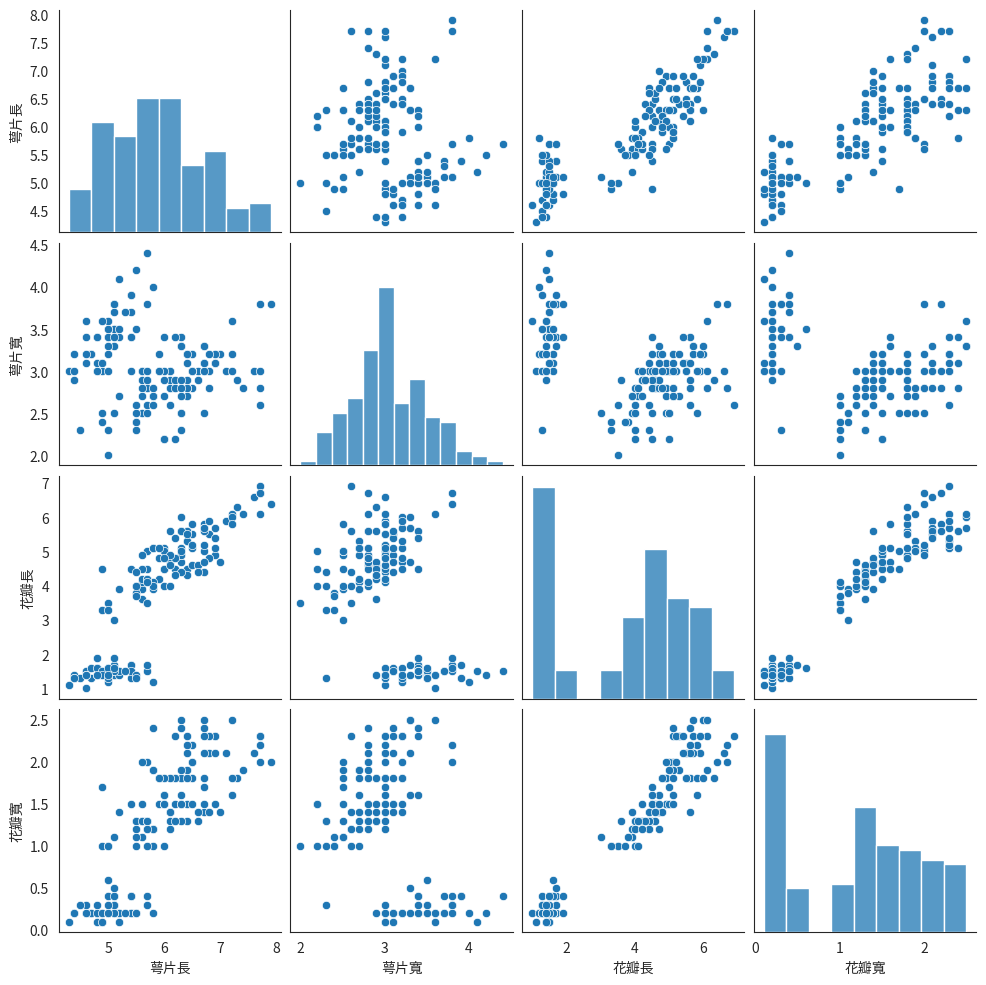

In [11]:
sns.pairplot(iris)

切割為訓練集與測試集

In [16]:
X = iris.iloc[:, 0:4].values
y = iris.iloc[:, 4].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)



建立模型(資料不需標準化)

In [17]:
clf = DecisionTreeClassifier(criterion = "entropy", max_depth=3, random_state=0)
clf = clf.fit(X_train,y_train)

評估決策樹模型好壞

In [18]:
predictions = clf.predict(X_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

         山鳶尾       1.00      1.00      1.00        11
      維吉尼亞鳶尾       1.00      1.00      1.00         6
        雜色鳶尾       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



從另一個維度查看混淆矩陣結果

In [19]:
print(confusion_matrix(y_test,predictions))

[[11  0  0]
 [ 0  6  0]
 [ 0  0 13]]


視覺化呈現==>存出pdf檔

In [20]:
dot_data = tree.export_graphviz(clf, out_file=None) 
graph = graphviz.Source(dot_data) 
graph.render("iris")

'iris.pdf'

在jupyter notebook上呈現

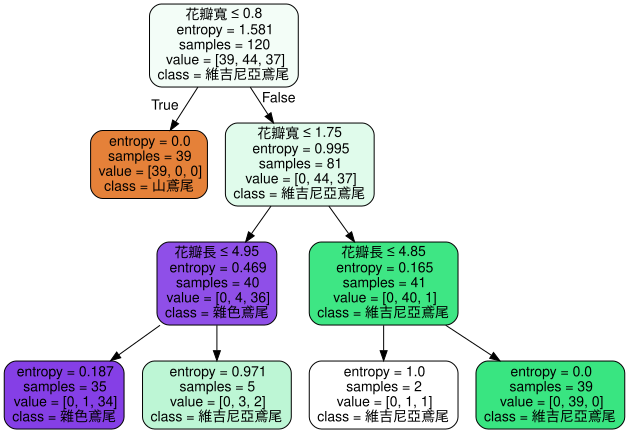

In [21]:
dot_data = tree.export_graphviz(clf, out_file=None, 
                                feature_names=list(iris.columns)[:4],  
                                class_names=clf.classes_,  
                                filled=True, rounded=True,  
                                special_characters=True)  
graph = graphviz.Source(dot_data)  
graph 

使用隨機森林與決策樹做比較

In [22]:
#使用隨機森林與決策樹做比較
from sklearn.ensemble import RandomForestClassifier

#n_estimator代表要使用多少CART樹（CART樹為使用GINI算法的決策樹）
rfc = RandomForestClassifier(n_estimators=100)

#從訓練組資料中建立隨機森林模型
rfc.fit(X_train,y_train)

#預測測試組的是否發生
rfc_pred = rfc.predict(X_test)

利用confusion matrix來看實際及預測的差異

In [23]:
print(confusion_matrix(y_test,rfc_pred))

[[11  0  0]
 [ 0  5  1]
 [ 0  0 13]]


利用classification report來看precision、recall、f1-score、support

In [24]:
print(classification_report(y_test,rfc_pred))

              precision    recall  f1-score   support

         山鳶尾       1.00      1.00      1.00        11
      維吉尼亞鳶尾       1.00      0.83      0.91         6
        雜色鳶尾       0.93      1.00      0.96        13

    accuracy                           0.97        30
   macro avg       0.98      0.94      0.96        30
weighted avg       0.97      0.97      0.97        30

